# 8.1.2 曲率凸性与局部极值

## 学习目标与先修知识

用方向曲率区分凸性（convexity）、严格极小与驻点（stationary point），解释非凸反例。

先修：8.1.1的目标、梯度（gradient）与Hessian，以及第3篇的特征值（eigenvalue）。 [本篇学习次序](../README.md)。

## 具体问题

一条算法只输出（output）“梯度接近零”。这够不够宣布找到最优清除参数（parameter）？比较碗形、鞍形和双井目标，看看相同的停止信号能代表多么不同的几何。

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
for x in [-1.,0.,1.]:
    print('x=',x,'f=',x**4/4-x*x/2,'梯度=',x**3-x,'曲率=',3*x*x-1)

x= -1.0 f= -0.25 梯度= 0.0 曲率= 2.0
x= 0.0 f= 0.0 梯度= 0.0 曲率= -1.0
x= 1.0 f= -0.25 梯度= 0.0 曲率= 2.0


## 模型假设

本节变量与目标都无量纲（dimensionless）。二次例子用对称矩阵（matrix），默认在整个实空间优化；双井函数只用来隔离非凸几何，不能直接解释为实际人体代价。讨论二阶充分条件时，假设目标在该点邻域二阶连续可微且该点是内部驻点。

## 数学解释与推导

### 曲率是沿方向的二阶变化

对二维点x和方向p，二阶展开为
$$f(x+p)=f(x)+\nabla f(x)^Tp+\frac12p^TH(x)p+o(\|p\|^2).$$
余项相对于 $\|p\|^2$ 趋于零，表达“足够近时”。二次型 $p^THp$ 为各方向提供曲率：正定（positive definite）表示非零方向都为正；半正定（positive semidefinite）允许平坦方向。对称H可在正交（orthogonality）特征方向分解，$p^THp=\sum_j\lambda_j z_j^2$。

驻点处H正定，推出严格局部最小；若有正负两类特征值，就是鞍点；仅半正定则二阶检验可能无法决定。$x^4$ 与 $-x^4$ 在零处有相同的一阶、二阶导数（derivative），却分别是最小和最大。

### 凸性需要覆盖一段范围

凸集（convex set）包含任意两点之间的整段线段。凸性要求在该域上
$$f((1-t)x+ty)\le(1-t)f(x)+tf(y),\quad 0\le t\le1.$$
对二阶连续可微函数，在开放凸域上处处H半正定等价于凸性。只看某个点不够。凸函数的一阶支撑不等式是 $f(y)\ge f(x)+\nabla f(x)^T(y-x)$；因此内部驻点是全局最小。

对正定二次目标，解 $Hx^*=b$ 后配方得到
$$f(x)-f(x^*)=\frac12(x-x^*)^TH(x-x^*)>0\quad(x\ne x^*).$$
这同时证明存在、唯一与全局最优。一般严格凸只能保证最小点至多一个，仍需检查能否达到；例如 $e^x$ 在实线上没有最小点。

双井目标 $f=x^4/4-x^2/2=(x^2-1)^2/4-1/4$ 在±1取得同样最小值，0却是局部最大。它是以后检验算法误报的固定反例。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]


def solve_linear(matrix, right):
    """Partial-pivot elimination for the tiny classroom systems."""
    rows = [list(map(float, row))+[float(value)] for row, value in zip(matrix, right)]
    size = len(rows)
    for column in range(size):
        pivot = max(range(column, size), key=lambda i: abs(rows[i][column]))
        if abs(rows[pivot][column]) < 1e-12:
            return None
        rows[column], rows[pivot] = rows[pivot], rows[column]
        scale = rows[column][column]
        rows[column] = [value/scale for value in rows[column]]
        for i in range(size):
            if i != column:
                factor = rows[i][column]
                rows[i] = [a-factor*b for a, b in zip(rows[i], rows[column])]
    return [row[-1] for row in rows]

## 对照实验

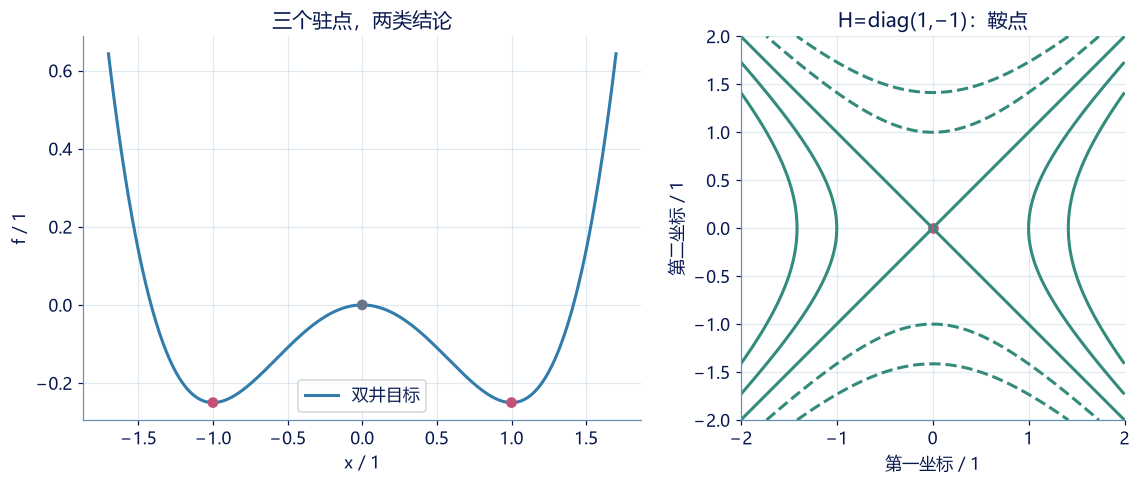

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,4.3))
x=np.linspace(-1.7,1.7,300)
axes[0].plot(x,x**4/4-x*x/2,color=BLUE,label='双井目标')
axes[0].scatter([-1,0,1],[-.25,0,-.25],c=[PINK,GRAY,PINK],zorder=3)
axes[0].set(xlabel='x / 1',ylabel='f / 1',title='三个驻点，两类结论');axes[0].legend()
xx,yy=np.meshgrid(np.linspace(-2,2,80),np.linspace(-2,2,80))
axes[1].contour(xx,yy,(xx*xx-yy*yy)/2,levels=[-1,-.5,0,.5,1],colors=GREEN)
axes[1].scatter([0],[0],color=PINK);axes[1].set(xlabel='第一坐标 / 1',ylabel='第二坐标 / 1',title='H=diag(1,−1)：鞍点');axes[1].set_aspect('equal')
plt.show()

### 独立核验与边界

In [5]:
H=np.array([[2.,1.],[1.,3.]]);b=np.array([1.,2.]);best=solve_linear(H,b)
for point in ([0,0],[2,-1],[-1,3]):
    delta=np.array(point)-best
    np.testing.assert_allclose(quadratic(H,b,point)[0]-quadratic(H,b,best)[0],delta@H@delta/2)
assert np.linalg.eigvalsh(H).min()>0
assert (0.1**4)>0 and -(0.1**4)<0
print('配方恒等式通过；零Hessian反例保留。')

配方恒等式通过；零Hessian反例保留。


## 结果解释

双井图中三个标记的梯度都为零，只有两侧是最小点。鞍形图则显示，沿一个方向下降并不意味着沿所有方向都下降。后续算法中的“梯度达标”因此只能按目标的已知条件解释，不能把非凸问题的停止结论标签改名为全局最优。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：求严格凸二次目标的最小点

给定二维正定（positive definite）对称矩阵（matrix）H和线性项b，求唯一最小点。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
) -> list[float]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵 H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |

**返回值**

直接返回 minimizer（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `minimizer` | `list[float]` | 按原坐标顺序返回H⁻¹b。 | 无量纲 |

**计算规则**

求解Hx=b，返回两个坐标，不返回矩阵的逆。

**约束与边界**

- H为2×2正定对称矩阵，最小特征值（eigenvalue）≥0.1，最大特征值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵 H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 0.0], [0.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [2.0, 8.0] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 0.0], [0.0, 4.0]]
linear = [2.0, 8.0]

result = solve(matrix, linear)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| minimizer | 按原坐标顺序返回H⁻¹b。 | [1.0, 2.0] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 2.0]
```

**样例解释**

两个坐标分别为2/2和8/4，即[1,2]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：求严格凸二次目标的最小点](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-linear-minimum)

### 第 2 题 · 多项选择题：驻点不一定最小

f(x)=x⁴/4−x²/2。在x=0及x=±1分别能得到哪些结论？

- **A.** x=0的梯度（gradient）为零，所以是全局最小。
- **B.** x=0的二阶导数（derivative）为−1，是严格局部最大。
- **C.** x=±1为全局最小，函数值都是−1/4。
- **D.** 三个驻点（stationary point）足以证明函数为凸。

[作答：驻点不一定最小](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-stationary-counterexample)

### 第 3 题 · 多项选择题：零曲率没有给出结论

f₁(x)=x⁴和f₂(x)=−x⁴在0都有一阶、二阶导数（derivative）为0。哪些判断正确？

- **A.** 二阶导数为0说明都不是极值。
- **B.** f₁在0是严格最小。
- **C.** f₂在0是严格最大。
- **D.** 海森矩阵（Hessian matrix）半正定（positive semidefinite）在单个点不能保证该点最小。

[作答：零曲率没有给出结论](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-hessian-zero)

### 第 4 题 · 多项选择题：凸性结论的范围

在开放凸域上，f二阶连续可微。下列哪些条件或结论正确？

- **A.** 海森矩阵（Hessian matrix）在全域半正定（positive semidefinite）等价于f凸。
- **B.** 只在初值（initial condition）处检查海森矩阵（Hessian matrix）即可判定全域凸。
- **C.** 凸函数的任一驻点（stationary point）若位于域内，都是全局最小点。
- **D.** 严格凸且最小值能达到时，最小点唯一。

[作答：凸性结论的范围](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-convex-domain)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第2—4章：凸集、凸函数与最优性。

推导、实现与核验均在本节完整给出，参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-01-目标函数与优化几何/explore/) · [本篇目录](../README.md)